#### Quantum distribution model
This program does not produce a time series, but produces points (z,v) which approximate the correct distribution for the quantum model. We first use the q-distribution to select a value of z. The expected variance E[v | z] is given by q-variance. We assume actual variance follows an inverse-gamma distribution. The actual variance is then computed from a time series of T points.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic, norm, skewnorm

import numpy as np
import pandas as pd

def generate_multi_period_dataset(t_periods_list, n_days=100000, sigma=0.1):
    """
    Loops over a list of period lengths T, runs the simulation for each,
    and returns a single combined DataFrame.
    
    Parameters:
    - t_periods_list (list of int): List of T values to simulate (e.g., [5, 10, 20, 50, 100])
    - n_days (int): Total number of days to divide for each simulation
    - sigma (float): Base standard deviation parameter
    
    Returns:
    - pd.DataFrame: Combined DataFrame containing rows from all simulated periods
    """
    # Use a list to collect DataFrames (much faster than repeatedly appending to a single DataFrame)
    dfs = []
    
    for t in t_periods_list:
        print(f"Simulating period T = {t}...")
        df_t = simulate_q_periods(n_days=n_days, t_period=t, sigma=sigma)
        dfs.append(df_t)
        
    # Combine all individual DataFrames into a single giant DataFrame
    # ignore_index=True resets the index across the combined rows
    combined_df = pd.concat(dfs, ignore_index=True)
    
    return combined_df

def calculate_skewnorm_loc(vmn, a, scale):
    """
    Computes the exact 'loc' parameter needed for a Skew-Normal distribution
    on log(v) such that the expected value E[v] equals vmn.
    """
    # 1. Compute the shape-adjusted delta component
    delta_term = (a * scale) / np.sqrt(1 + a**2)    
    # 2. Evaluate the standard normal CDF
    phi_val = norm.cdf(delta_term)    
    # 3. Apply the closed-form MGF inversion formula
    loc = np.log(vmn) - (scale**2 / 2) - np.log(2) - np.log(phi_val)    
    return loc

a_param = 1.35  #1.35        # Shape parameter for skew-normal, determined from score_submission.py
scale_param = 1.02  #1.39    # Scale parameter for skew-normal
#print(f"The exact 'loc' value required is: {adjusted_loc:.6f}")


def simulate_q_periods(n_days=100000, t_period=100, sigma=0.1):
    num_periods = int(n_days // t_period)
    
    z_periods = np.zeros(num_periods)
    v_periods = np.zeros(num_periods)
    t_periods = np.full(num_periods, t_period)

    #alpha = 2.1  # + 1/cv**2 
    #betafac = alpha - 1
    
    for i in range(num_periods):
        state_n = np.random.poisson(lam=0.5)
        sigma_n = sigma * np.sqrt(2 * state_n + 1)
        z_period = np.random.normal(loc=0.0, scale=sigma_n)
        
        expected_variance = sigma**2 + 0.5 * (z_period**2)
        #beta = betafac * expected_variance  
        
        # Note: scale parameter for np.random.gamma is 1/beta if you want a mean of beta/betafac
        # actual_variance = 1 / np.random.gamma(alpha, 1/beta)   # inverse gamma
        adjusted_loc = calculate_skewnorm_loc(expected_variance, a_param, scale_param)
        actual_variance = np.exp(skewnorm.rvs(a=a_param, loc=adjusted_loc, scale=scale_param))  # skew-normal for log(v)
        
        z_daily_series = np.random.normal(loc=0.0, scale=np.sqrt(actual_variance), size=t_period)
        measured_v = np.var(z_daily_series, ddof=1)
        
        z_periods[i] = z_period 
        v_periods[i] = measured_v

    df = pd.DataFrame({
        'z': z_periods,
        'v': v_periods,
        't': t_periods
    })
    
    return df

target_periods = 5*np.arange(1, 27) 

# Generate the master dataframe
sigma0 = 0.259
n_days = 295*252*20  # 295 stocks over 20 years
df = generate_multi_period_dataset(t_periods_list=target_periods, n_days=n_days, sigma=sigma0)

print(f"\nFinal DataFrame Shape: {df.shape}")
print(df.sample(5)) # View 5 random rows across different T values

# Now bin the data
bins = np.arange(-1, 1.05, 0.05)
df['bin_mid'] = pd.cut(df['z'], bins).apply(lambda z: z.mid).astype(float)
binned_summary = df.groupby('bin_mid', observed=True)['v'].mean().reset_index()


Simulating period T = 5...
Simulating period T = 10...
Simulating period T = 15...
Simulating period T = 20...
Simulating period T = 25...
Simulating period T = 30...
Simulating period T = 35...
Simulating period T = 40...
Simulating period T = 45...
Simulating period T = 50...
Simulating period T = 55...
Simulating period T = 60...
Simulating period T = 65...
Simulating period T = 70...
Simulating period T = 75...
Simulating period T = 80...
Simulating period T = 85...
Simulating period T = 90...
Simulating period T = 95...
Simulating period T = 100...
Simulating period T = 105...
Simulating period T = 110...
Simulating period T = 115...
Simulating period T = 120...
Simulating period T = 125...
Simulating period T = 130...

Final DataFrame Shape: (1146145, 3)
                z         v    t
969548   0.450067  0.086717   75
734084   0.004150  0.022167   35
952546  -1.208857  0.871983   70
1128647 -0.094133  0.135350  125
124033  -0.337385  0.024683    5


We now check the coefficient of variation CV(T) of variance across different windows T. For these period lengths it should be above about 1.5.

Period (T)   | Mean Variance   | Std Dev Variance   | Global CV(T)
-----------------------------------------------------------------
5            | 0.134358        | 0.300787           | 2.2387      
10           | 0.134003        | 0.259456           | 1.9362      
15           | 0.132786        | 0.237533           | 1.7888      
20           | 0.133392        | 0.235601           | 1.7662      
25           | 0.134864        | 0.238848           | 1.7710      
30           | 0.135666        | 0.249998           | 1.8427      
35           | 0.134827        | 0.235424           | 1.7461      
40           | 0.132173        | 0.237665           | 1.7981      
45           | 0.133910        | 0.239611           | 1.7893      
50           | 0.136264        | 0.256311           | 1.8810      
55           | 0.133085        | 0.241629           | 1.8156      
60           | 0.133247        | 0.225848           | 1.6950      
65           | 0.134504        | 0.236472           | 1.7581   

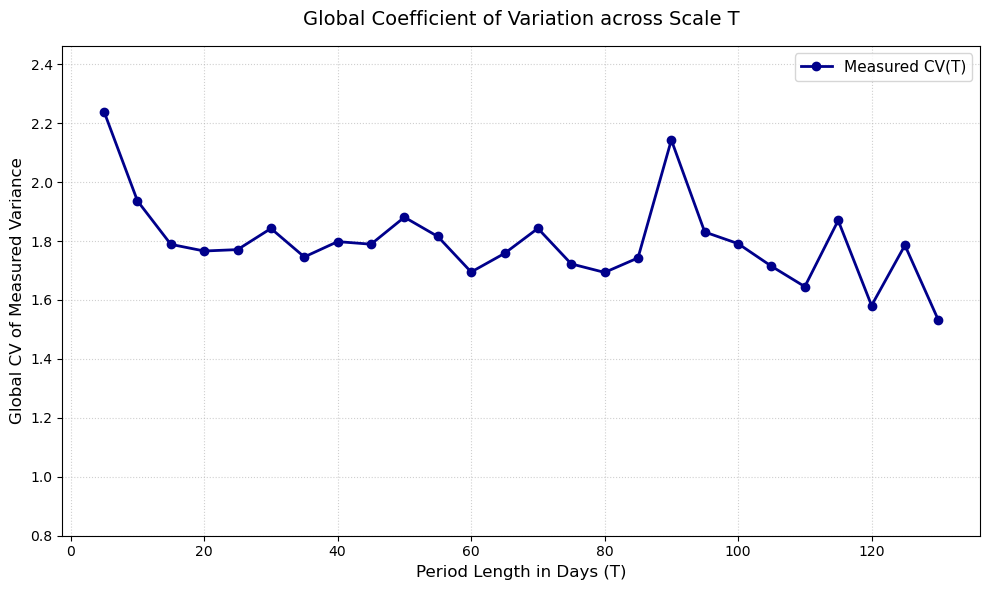

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_cv_convergence(dataframe):
    """
    Computes global CV(T) for each period T, prints a summary table,
    and plots the decay curve showing convergence toward the target line.
    
    Parameters:
    - dataframe (pd.DataFrame): The master aggregated dataframe containing 'v' and 't'
    """
    # 1. Group and calculate statistics
    summary = dataframe.groupby('t')['v'].agg(['mean', 'std']).reset_index()
    summary['global_cv'] = summary['std'] / summary['mean']
    
    # 2. Print summary table to console
    print(f"{'Period (T)':<12} | {'Mean Variance':<15} | {'Std Dev Variance':<18} | {'Global CV(T)':<12}")
    print("-" * 65)
    for _, row in summary.iterrows():
        print(f"{int(row['t']):<12} | {row['mean']:<15.6f} | {row['std']:<18.6f} | {row['global_cv']:<12.4f}")
        
    # 3. Generate the convergence plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot measured CV curve
    ax.plot(summary['t'], summary['global_cv'], marker='o', color='darkblue', 
            linewidth=2, label='Measured CV(T)')
    
    # Plot asymptotic theoretical target line
    # ax.axhline(y=1.0, color='crimson', linestyle='--', linewidth=1.5, label='Theoretical Lower Bound (CV = 1.0)')
    
    # Visual Adjustments
    ax.set_title('Global Coefficient of Variation across Scale T', fontsize=14, pad=15)
    ax.set_xlabel('Period Length in Days (T)', fontsize=12)
    ax.set_ylabel('Global CV of Measured Variance', fontsize=12)
    
    # Ensure grid visibility and formatting
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=11, loc='upper right')
    
    # Automatically bound y-axis cleanly depending on sampling noise ranges
    ax.set_ylim(0.8, max(summary['global_cv'].max() * 1.1, 1.5))
    
    plt.tight_layout()
    plt.show()

# --- Execution Example ---
plot_cv_convergence(df)


Now plot the results.

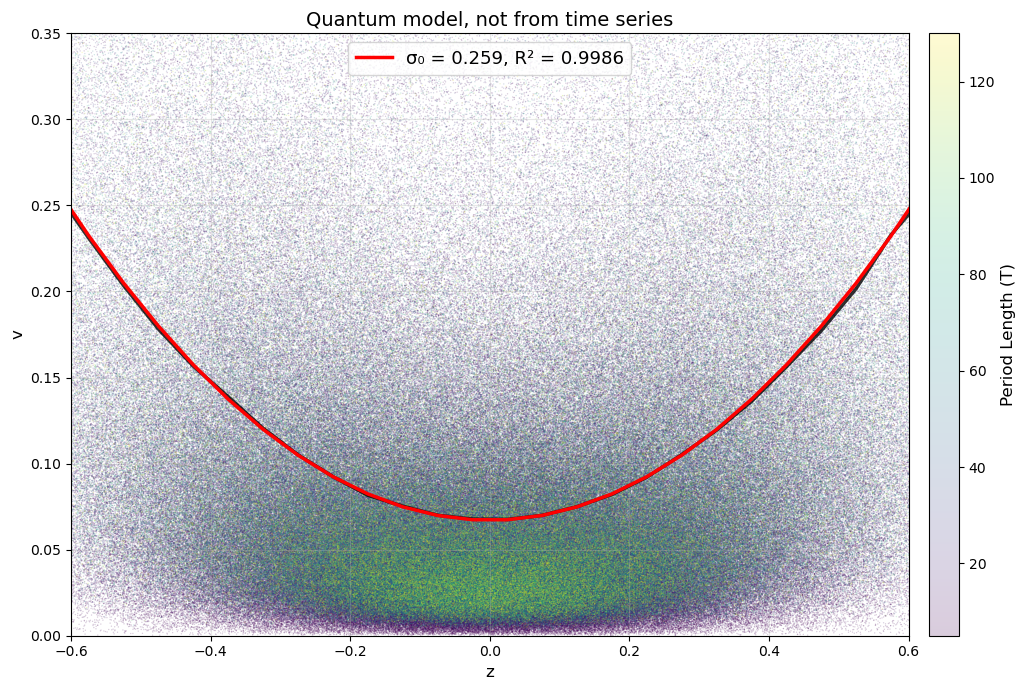

Text(0.5, 1.0, 'All stocks T=2, 4, 8, 16 weeks – Q-Variance')

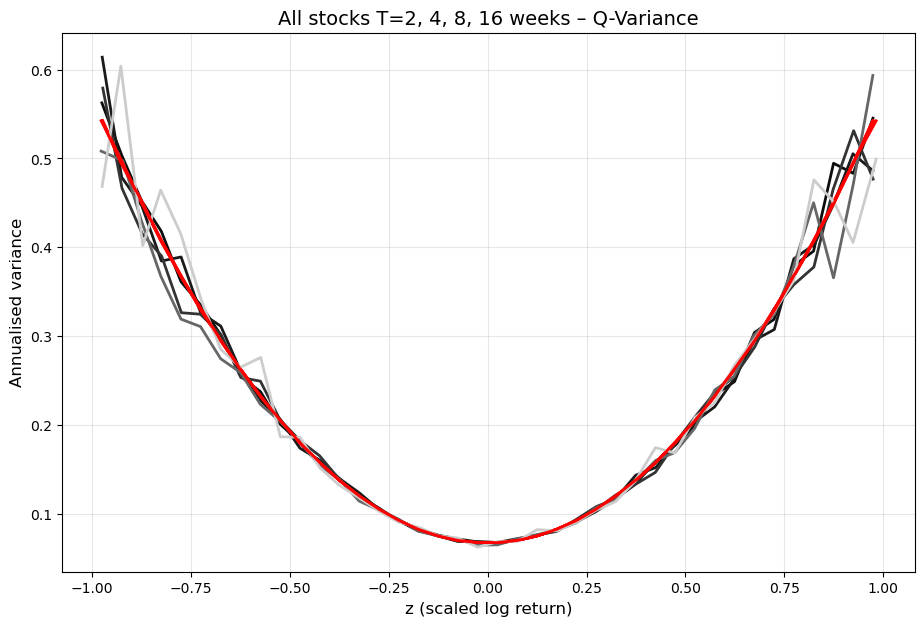

In [39]:
def q_variance_model(z, sigma_0_sq):
    return sigma_0_sq + z**2 / 2


fig, ax = plt.subplots(figsize=(11, 7))  # Slightly widened to make room for the colorbar

# Map the 't' column to the 'c' parameter and choose a colormap (e.g., 'viridis', 'plasma', or 'coolwarm')
scatter = ax.scatter(
    df['z'], 
    df['v'], 
    c=df['t'],          # Set colour based on period length T
    cmap='viridis',     # Choose a distinct colormap
    alpha=0.2,          # Slight alpha adjustment helps see overlapping points from different T
    s=1, 
    edgecolors='none'
)

qvarcurve = q_variance_model(binned_summary['bin_mid'], sigma0**2)
ss_res = np.sum((binned_summary['v'] - qvarcurve)**2)
ss_tot = np.sum((binned_summary['v'] - np.mean(binned_summary['v']))**2)
r_squared = 1 - ss_res / ss_tot

# Plot your binned summary trend line
ax.plot(binned_summary['bin_mid'], binned_summary['v'], color='black', linewidth=2.5, alpha=0.8)

ax.plot(binned_summary['bin_mid'], qvarcurve,
         color='red', lw=2.5,
         label=f'σ₀ = {sigma0:.3f}, R² = {r_squared:.4f}')

# Add a colorbar to act as a legend for the continuous T values
cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Period Length (T)', fontsize=12)

# Axis limits and labels
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(0, 0.35)
ax.set_xlabel('z', fontsize=12)
ax.set_ylabel('v', fontsize=12)

ax.grid(alpha=0.3)

plt.title('Quantum model, not from time series', fontsize=14)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()

plt.show()

# now plot q-variance for different periods T
TVEC = [5, 10, 20, 40, 80]

fig, ax = plt.subplots(figsize=(11, 7))
popt = [0.2586, 0.0214]  # same as optimized fit to data  # for competition score should fit original parabola
#plt.plot(binned.z_mid, binned['v'], 'b-', lw=3,label='all T')  
#plt.plot(binned.z_mid, qvarcurve, 'red', lw=3, label=f'σ₀ = {popt[0]:.3f}, zoff = {popt[1]:.3f}, R² = {r2:.3f}')

for Tcur in TVEC:
    datacur = df[(df["t"] == Tcur)].copy()
    binned = (datacur.assign(z_bin=pd.cut(datacur.z, bins=bins, include_lowest=True))
                   .groupby('z_bin',observed=False)
                   .agg(z_mid=('z', 'mean'), v=('v', 'mean'))
                   .dropna())
    popt, _ = curve_fit(q_variance_model, binned.z_mid, binned["v"], p0=[0.02])  # custom fit
    ###binned.z_mid = binned.z_mid - Tcur/252*popt[0]**2/2  # correct for offset
    r2 = 1 - np.sum((binned["v"] - qvarcurve)**2) / np.sum((binned["v"] - binned["v"].mean())**2)
    #print(f"T = {Tcur} σ₀ = {popt[0]:.4f}  zoff = {popt[1]:.4f}  R² = {r2:.4f}")
    colcur = str(Tcur/100)
    plt.plot(binned.z_mid, binned['v'], c=colcur, lw=2,label=f'T = {Tcur/5:.0f}, R² = {r2:.3f}') 
    plt.plot(binned.z_mid, qvarcurve, c='red', lw=2,label=f'q-variance') 

plt.xlabel('z (scaled log return)', fontsize=12)
plt.ylabel('Annualised variance', fontsize=12)
#plt.legend(fontsize=10, loc='upper center')
plt.grid(alpha=0.3)
plt.title('All stocks T=2, 4, 8, 16 weeks – Q-Variance', fontsize=14)


Now perform linear regression to compute the best-fit quadratic coefficients for each T. Note that in the quantum model the coefficient is fixed at 1/2.

Period (T)   | Intercept (a)   | Slope b(T)      | Theoretical Target
--------------------------------------------------------------------
5            | 0.064912        | 0.5170          | 0.5000
10           | 0.066944        | 0.4993          | 0.5000
15           | 0.068744        | 0.4801          | 0.5000
20           | 0.068866        | 0.4824          | 0.5000
25           | 0.066311        | 0.5121          | 0.5000
30           | 0.065669        | 0.5214          | 0.5000
35           | 0.068162        | 0.4916          | 0.5000
40           | 0.066817        | 0.4892          | 0.5000
45           | 0.065192        | 0.5161          | 0.5000
50           | 0.065294        | 0.5251          | 0.5000
55           | 0.067913        | 0.4788          | 0.5000
60           | 0.066701        | 0.4974          | 0.5000
65           | 0.066361        | 0.5057          | 0.5000
70           | 0.062807        | 0.5222          | 0.5000
75           | 0.067571        | 0.4892          

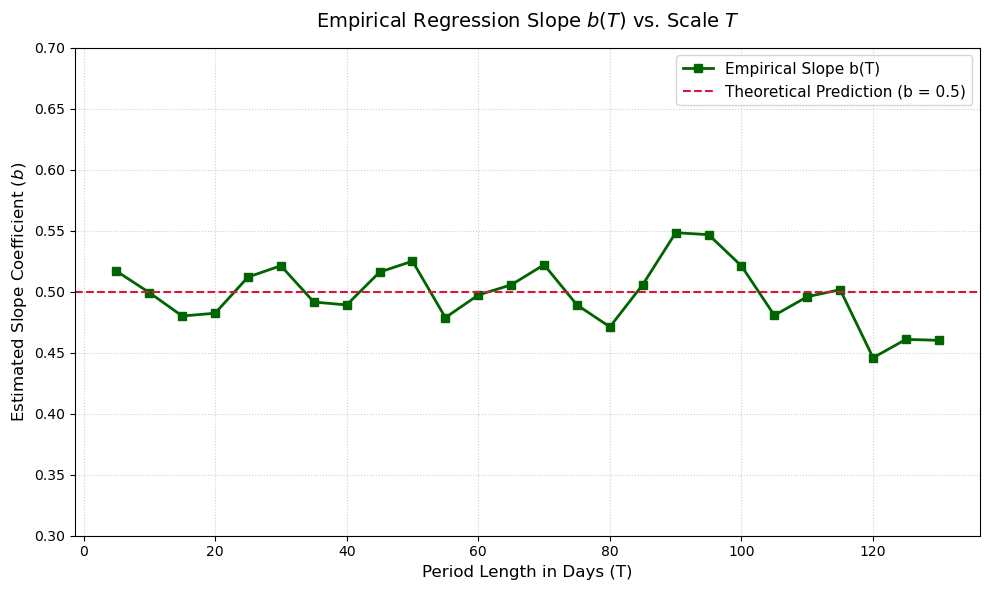

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def analyze_and_plot_slopes(dataframe):
    """
    Performs a linear regression y = a + b * z^2 for each period T,
    extracts the slope b(T), prints a summary table, and plots b(T) vs T.
    
    Parameters:
    - dataframe (pd.DataFrame): The master combined dataframe containing 'z', 'v', and 't'
    """
    # Group by the unique period lengths present in the dataframe
    grouped = dataframe.groupby('t')
    
    t_list = []
    b_list = []
    a_list = []
    
    print(f"{'Period (T)':<12} | {'Intercept (a)':<15} | {'Slope b(T)':<15} | {'Theoretical Target':<18}")
    print("-" * 68)
    
    for t_val, group in grouped:
        x = group['z']**2
        y = group['v']
        
        # np.polyfit(x, y, 1) fits a 1st-degree polynomial: y = slope * x + intercept
        # It handles ordinary least squares regression natively
        slope, intercept = np.polyfit(x, y, 1)
        
        t_list.append(t_val)
        b_list.append(slope)
        a_list.append(intercept)
        
        print(f"{t_val:<12} | {intercept:<15.6f} | {slope:<15.4f} | 0.5000")
        
    # --- Visualization Code ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot empirical slope values
    ax.plot(t_list, b_list, marker='s', markersize=6, color='darkgreen', 
            linestyle='-', linewidth=2, label='Empirical Slope b(T)')
    
    # Plot the expected theoretical horizontal line
    ax.axhline(y=0.5, color='crimson', linestyle='--', linewidth=1.5, 
               label='Theoretical Prediction (b = 0.5)')
    
    # Visual Layout Polish
    ax.set_title(r'Empirical Regression Slope $b(T)$ vs. Scale $T$', fontsize=14, pad=15)
    ax.set_xlabel('Period Length in Days (T)', fontsize=12)
    ax.set_ylabel(r'Estimated Slope Coefficient ($b$)', fontsize=12)
    
    # Configure grid lines and legend
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=11, loc='best')
    
    # Force y-axis scaling to bracket the target symmetrically 
    ax.set_ylim(0.3, 0.7)
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
analyze_and_plot_slopes(df)


Now compare the total variance distribution with a skew-normal curve.

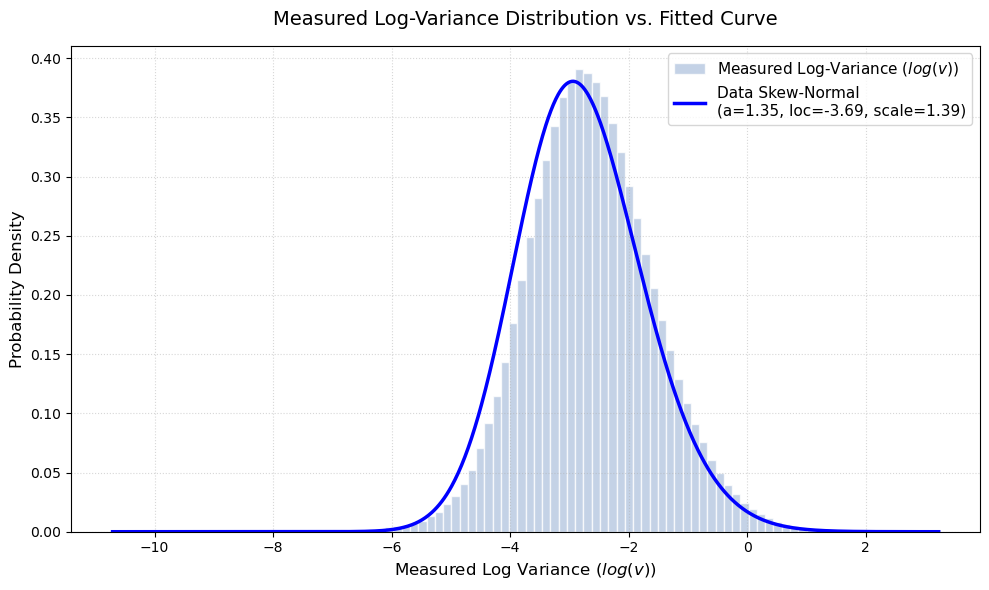

In [41]:
from scipy.stats import invgamma

def skewnorm_pdf(x, a, loc, scale):
    return skewnorm.pdf(x, a, loc, scale)

def plot_variance_histogram_with_fit(dataframe):
    """
    Plots a density histogram of measured variance 'v' 
    and overlays a fitted Inverse-Gamma probability density function (PDF).
    
    Parameters:
    - dataframe (pd.DataFrame): Dataframe containing the 'v' column
    """
    # Extract the variance array
    v_data = np.log(dataframe['v'].dropna().values)
    #v_data = v_data[v_data <= 0.3]
    
    # 1. Fit the Inverse-Gamma distribution parameters to the empirical data
    # invgamma.fit returns: shape (alpha), location (loc), and scale (beta)
    # Fixing floc=0 ensures the distribution starts at 0 and doesn't introduce an arbitrary shift
    #alpha_fit, loc_fit, beta_fit = invgamma.fit(v_data, floc=0)
    #alpha_fit = 1.5
    #beta_fit = 0.05
    #print("--- Fitted Inverse-Gamma Parameters ---")
    #print(f"Shape (alpha): {alpha_fit:.4f}")
    # print(f"Shape (loc): {loc_fit:.4f}")  # loc=0
    #print(f"Scale (beta) : {beta_fit:.6f}")
    #print(f"Location     : {loc_fit} (Fixed)")

    
    # 2. Initialize the plot layout
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 3. Plot the total density histogram
    # density=True normalizes the histogram so the area under the bars equals 1.0
    counts, bins, _ = ax.hist(
        v_data, 
        bins=100, 
        density=True, 
        color='lightsteelblue', 
        edgecolor='white', 
        alpha=0.75, 
        label='Measured Log-Variance ($log(v)$)'
    )
    # 4. Generate points for the continuous curve overlay
    # Using a range from just above 0 out to the maximum value inside the histogram bins
    x_range = np.linspace(np.min(v_data), np.max(bins), 1000)
    # fitted_pdf = invgamma.pdf(x_range, alpha_fit, loc=loc_fit, scale=beta_fit)   # inverse-gamma

    a_fit, loc_fit, scale_fit = skewnorm.fit(v_data)
    fitted_pdf = skewnorm.pdf(x_range, a_fit, loc_fit, scale_fit)     # skew-normal
    data_pdf = skewnorm.pdf(x_range, 1.35, -3.69, 1.39) 
    a_param = 1.35        # Shape parameter for skew-normal, determined from score_submission.py


    # 5. Overlay the Fitted PDF Curve
    #ax.plot(x_range,fitted_pdf,color='crimson',linewidth=2.5,
            #label=f'Model Skew-Normal\n(a={a_fit:.3f}, loc={loc_fit:.3f}, scale={scale_fit:.3f})' )
    ax.plot(x_range,data_pdf,color='blue',linewidth=2.5,
            label=f'Data Skew-Normal\n(a=1.35, loc=-3.69, scale=1.39)' )
    
    # Visual Layout Polish
    ax.set_title('Measured Log-Variance Distribution vs. Fitted Curve', fontsize=14, pad=15)
    ax.set_xlabel('Measured Log Variance ($log(v)$)', fontsize=12)
    ax.set_ylabel('Probability Density', fontsize=12)
    
    # Set x-limits safely to avoid extremely long empty tails from outliers
    #ax.set_xlim(0, np.percentile(v_data, 99.5)) 
    #ax.set_xlim(-8,4)
    
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(fontsize=11, loc='upper right')
    
    plt.tight_layout()
    plt.show()

plot_variance_histogram_with_fit(df)

# Save as a standard CSV file (supported out-of-the-box everywhere)
#df.to_csv('simulated_variance_data.csv', index=False)
#print("File successfully saved as 'simulated_variance_data.csv'")

